# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will build a object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but don't code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5. Device test that demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [73]:
import random

suits = ("Hearts", "Diamonds", "Spades", "Clubs")
ranks = (
    "Two",
    "Three",
    "Four",
    "Five",
    "Six",
    "Seven",
    "Eight",
    "Nine",
    "Ten",
    "Jack",
    "Queen",
    "King",
    "Ace",
)
values = {
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5,
    "Six": 6,
    "Seven": 7,
    "Eight": 8,
    "Nine": 9,
    "Ten": 10,
    "Jack": 10,
    "Queen": 10,
    "King": 10,
    "Ace": 11,
}

class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def __str__(self):
        return f"{self.rank} of {self.suit}"


class Deck:
    def __init__(self):
        self.deck = []
        for suit in suits:
            for rank in ranks:
                self.deck.append((suit, rank))

    def shuffle(self):
        random.shuffle(self.deck)

    def deal(self):
        take_cards = self.deck.pop()
        return take_cards


class Hand:
    def __init__(self,values):
        self.cards = []
        self.values = values
        self.value = 0
        self.aces = 0

    def add_cards(self, card):
        self.cards.append(card)
        self.value += values[card[1]]

    def adjust_for_ace(self):
        if self.cards[0][1] == "Ace" or self.cards[1][1] == "Ace":
            if self.value < 11:
                values["Ace"] = 11
            elif self.value > 10:
                values["Ace"] = 1


class Chips:
    def __init__(self):
        self.total = 200
        self.bet = 0

    def win_bet(self):
        self.total = self.total + self.bet

    def lose_bet(self):
        self.total = self.total - self.bet

    def push(self):
        self.total = self.total


def take_bet(C):
    C.bet = int(input("enter your bet please : "))
    print("Total \t Bet",C.total,C.bet)
    if C.total == 0 and C.bet > C.total:
        raise Exception("You got 0 money left, you lost")
    while C.bet > C.total or C.bet < 0 or not (isinstance(C.bet, int)):
        C.bet = int(input("enter your bet please : "))


def hit(D, hand):
    hand.add_cards(D.deal())
    hand.adjust_for_ace()


def hit_or_stand(D, hand):
    while True:
        hit_stand = input("do you want to hit or stand ?  ").lower()
        if hit_stand == "hit" or hit_stand == "h":
            hit(D, hand)
        else:
            print("PLAYER stand, DEALER is playing")
            return False
        return True


def show_some(player_hand, dealer_hand):
    print("PLAYER cards : ")
    print(player_hand.cards)
    print("DEALER cards : ")
    print(dealer_hand.cards[0])


def show_all(player_hand, dealer_hand):
    print("PLAYER cards : ")
    print(player_hand.cards)
    print("DEALER cards : ")
    print(dealer_hand.cards)


def player_busts(C, player_hand, dealer_hand):
    C.lose_bet()
    print(" Player BUST ")


def player_wins(C, player_hand, dealer_hand):
    C.win_bet()
    print(" Player WIN ")


def dealer_busts(C, player_hand, dealer_hand):
    C.win_bet()
    print(" Dealer BUST ")


def dealer_wins(C, player_hand, dealer_hand):
    C.lose_bet()
    print(" Dealer WIN ")


def push(C, player_hand, dealer_hand):
    print("PUSH")
    C.push()


def play_again():
    return input("do you want to play another hand ? ").lower().startswith("y")




In [74]:
def main():
    win = 0
    lose = 0
    tie = 0
    print("*****BLACKJACK GAME******")
    print(
        "INSTRUCTION: 1)Bet should be lower than your total money or equal to it (200 is the current)"
    )
    print("2)Answer with y/n OR yes/no when you want to play another hand")
    print("3)answer with  H/S OR hit/stand  to hit or stand")
    C = Chips()
    while True:
        D = Deck()
        D.shuffle()
        player_hand = Hand(values)
        dealer_hand = Hand(values)
        player_hand.add_cards(D.deal())
        player_hand.add_cards(D.deal())
        dealer_hand.add_cards(D.deal())
        dealer_hand.add_cards(D.deal())
        take_bet(C)
        show_some(player_hand, dealer_hand)
        while hit_or_stand(D, player_hand):
            show_some(player_hand, dealer_hand)
            if player_hand.value > 21:
                show_all(player_hand, dealer_hand)
                player_busts(C, player_hand, dealer_hand)
                lose = lose + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie  =  {tie}")
                break
        if player_hand.value <= 21:
            while dealer_hand.value < 17:
                hit(D, dealer_hand)
            show_all(player_hand, dealer_hand)
            if dealer_hand.value > 21:
                dealer_busts(C, player_hand, dealer_hand)
                win = win + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie  =  {tie}")
            elif dealer_hand.value > player_hand.value:
                dealer_wins(C, player_hand, dealer_hand)
                lose = lose + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie  =  {tie}")
            elif dealer_hand.value < player_hand.value:
                player_wins(C, player_hand, dealer_hand)
                win = win + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie =  {tie}")
            else:
                push(C, player_hand, dealer_hand)
                tie = tie + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie =  {tie}")

        print(f"Your Total money ={C.total}")
        if play_again():
            continue
        else:
            print("Thanks for playing")
            print(
                f"Number of Wins  =  {win},Number of Loses =  {lose}, Number of Tie  =  {tie}"
            )
            break


main()

*****BLACKJACK GAME******
INSTRUCTION: 1)Bet should be lower than your total money or equal to it (200 is the current)
2)Answer with y/n OR yes/no when you want to play another hand
3)answer with  H/S OR hit/stand  to hit or stand


enter your bet please :  200


Total 	 Bet 200 200
PLAYER cards : 
[('Clubs', 'Nine'), ('Clubs', 'Three')]
DEALER cards : 
('Hearts', 'Two')


do you want to hit or stand ?   h


PLAYER cards : 
[('Clubs', 'Nine'), ('Clubs', 'Three'), ('Hearts', 'Ace')]
DEALER cards : 
('Hearts', 'Two')
PLAYER cards : 
[('Clubs', 'Nine'), ('Clubs', 'Three'), ('Hearts', 'Ace')]
DEALER cards : 
[('Hearts', 'Two'), ('Spades', 'Ace')]
 Player BUST 
Wins  =  0,Loses =  1, Tie  =  0
Your Total money =0


do you want to play another hand ?  h


Thanks for playing
Number of Wins  =  0,Number of Loses =  1, Number of Tie  =  0


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [76]:
values = {
    "Two": 1,
    "Three": 1,
    "Four": 1,
    "Five": 1,
    "Six": 1,
    "Seven": 0,
    "Eight": 0,
    "Nine": 0,
    "Ten": -1,
    "Jack": -1,
    "Queen": -1,
    "King": -1,
    "Ace": -1,
}

def main():
    win = 0
    lose = 0
    tie = 0
    print("*****BLACKJACK GAME******")
    print(
        "INSTRUCTION: 1)Bet should be lower than your total money or equal to it (200 is the current)"
    )
    print("2)Answer with y/n OR yes/no when you want to play another hand")
    print("3)answer with  H/S OR hit/stand  to hit or stand")
    C = Chips()
    while True:
        D = Deck()
        D.shuffle()
        player_hand = Hand(values)
        dealer_hand = Hand(values)
        player_hand.add_cards(D.deal())
        player_hand.add_cards(D.deal())
        dealer_hand.add_cards(D.deal())
        dealer_hand.add_cards(D.deal())
        take_bet(C)
        show_some(player_hand, dealer_hand)
        while hit_or_stand(D, player_hand):
            show_some(player_hand, dealer_hand)
            if player_hand.value > 21:
                show_all(player_hand, dealer_hand)
                player_busts(C, player_hand, dealer_hand)
                lose = lose + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie  =  {tie}")
                break
        if player_hand.value <= 3:
            while dealer_hand.value < 0:
                hit(D, dealer_hand)
            show_all(player_hand, dealer_hand)
            if dealer_hand.value > -2:
                dealer_busts(C, player_hand, dealer_hand)
                win = win + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie  =  {tie}")
            elif dealer_hand.value > player_hand.value:
                dealer_wins(C, player_hand, dealer_hand)
                lose = lose + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie  =  {tie}")
            elif dealer_hand.value < player_hand.value:
                player_wins(C, player_hand, dealer_hand)
                win = win + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie =  {tie}")
            else:
                push(C, player_hand, dealer_hand)
                tie = tie + 1
                print(f"Wins  =  {win},Loses =  {lose}, Tie =  {tie}")

        print(f"Your Total money ={C.total}")
        if play_again():
            continue
        else:
            print("Thanks for playing")
            print(
                f"Number of Wins  =  {win},Number of Loses =  {lose}, Number of Tie  =  {tie}"
            )
            break


main()

*****BLACKJACK GAME******
INSTRUCTION: 1)Bet should be lower than your total money or equal to it (200 is the current)
2)Answer with y/n OR yes/no when you want to play another hand
3)answer with  H/S OR hit/stand  to hit or stand


enter your bet please :  50


Total 	 Bet 200 50
PLAYER cards : 
[('Diamonds', 'Four'), ('Clubs', 'Seven')]
DEALER cards : 
('Clubs', 'Two')


do you want to hit or stand ?   h


PLAYER cards : 
[('Diamonds', 'Four'), ('Clubs', 'Seven'), ('Spades', 'Nine')]
DEALER cards : 
('Clubs', 'Two')


...

PLAYER cards : 
[('Diamonds', 'Jack'), ('Clubs', 'Five'), ('Diamonds', 'Ace'), ('Diamonds', 'Nine'), ('Hearts', 'Three')]
DEALER cards : 
('Diamonds', 'King')


do you want to hit or stand ?   s


PLAYER stand, DEALER is playing
PLAYER cards : 
[('Diamonds', 'Jack'), ('Clubs', 'Five'), ('Diamonds', 'Ace'), ('Diamonds', 'Nine'), ('Hearts', 'Three')]
DEALER cards : 
[('Diamonds', 'King'), ('Clubs', 'Two')]
 Dealer BUST 
Wins  =  2,Loses =  0, Tie  =  0
Your Total money =450


do you want to play another hand ?  n


Thanks for playing
Number of Wins  =  2,Number of Loses =  0, Number of Tie  =  0


7. Create a test scenario where one player using the above strategy is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from you code (perhaps implement a verbose/quiet mode) to reduce the output.

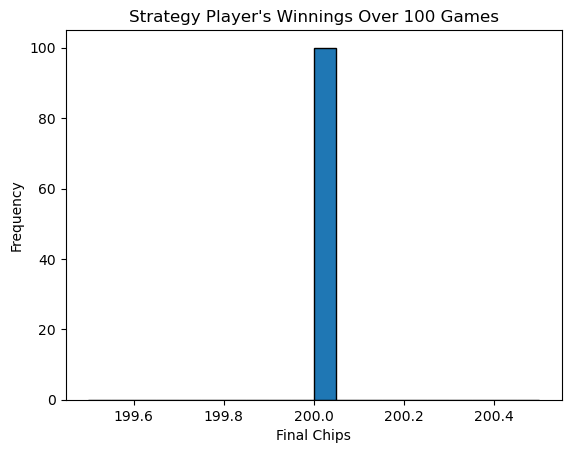

In [92]:
import random
import matplotlib.pyplot as plt

# Define card values, suits, and ranks
suits = ("Hearts", "Diamonds", "Spades", "Clubs")
ranks = ("Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine", "Ten", "Jack", "Queen", "King", "Ace")
values = {
    "Two": 2, "Three": 3, "Four": 4, "Five": 5, "Six": 6, "Seven": 7, "Eight": 8, "Nine": 9, "Ten": 10,
    "Jack": 10, "Queen": 10, "King": 10, "Ace": 11
}

# Define the Deck class
class Deck:
    def __init__(self):
        self.deck = []
        for suit in suits:
            for rank in ranks:
                self.deck.append((suit, rank))

    def shuffle(self):
        random.shuffle(self.deck)

    def deal(self):
        if len(self.deck) == 0:
            self.__init__()  # Reset the deck if it's empty
            self.shuffle()
        return self.deck.pop()

# Define the Hand class
class Hand:
    def __init__(self, values):
        self.cards = []
        self.values = values
        self.value = 0
        self.aces = 0

    def add_cards(self, card):
        self.cards.append(card)
        self.value += values[card[1]]

    def adjust_for_ace(self):
        if self.cards[0][1] == "Ace" or self.cards[1][1] == "Ace":
            if self.value < 11:
                values["Ace"] = 11
            elif self.value > 10:
                values["Ace"] = 1

# Define the Chips class
class Chips:
    def __init__(self, total=200):
        self.total = total
        self.bet = 0

    def win_bet(self):
        self.total += self.bet

    def lose_bet(self):
        self.total -= self.bet

# Define the hit function
def hit(D, hand):
    hand.add_cards(D.deal())
    hand.adjust_for_ace()

# Define the dealer's strategy (stand on 17 or higher)
def dealer_strategy(D, dealer_hand):
    while dealer_hand.value < 17:
        hit(D, dealer_hand)

# Define the card-counting strategy (hit if count < threshold, else stand)
def card_counting_strategy(D, player_hand, count, threshold=0):
    if count < threshold:
        hit(D, player_hand)
        return True  # Hit
    else:
        return False  # Stand

# Simulate a single round of the game
def simulate_round(D, players, dealer_hand, count, verbose=False):
    # Deal initial cards
    for player in players:
        player["hand"].add_cards(D.deal())
        player["hand"].add_cards(D.deal())
    dealer_hand.add_cards(D.deal())
    dealer_hand.add_cards(D.deal())

    # Players' turns
    for player in players:
        if player["strategy"] == "card_counting":
            while card_counting_strategy(D, player["hand"], count):
                pass
        else:
            while player["hand"].value < 17:
                hit(D, player["hand"])

    # Dealer's turn
    dealer_strategy(D, dealer_hand)

    # Determine results
    for player in players:
        if player["hand"].value > 21:
            player["chips"].lose_bet()
        elif dealer_hand.value > 21 or player["hand"].value > dealer_hand.value:
            player["chips"].win_bet()
        elif player["hand"].value < dealer_hand.value:
            player["chips"].lose_bet()
        else:
            pass  # Push (no change in chips)

# Main function to simulate 50 rounds
def main(verbose=False):
    # Initialize players
    players = [
        {"strategy": "card_counting", "chips": Chips(), "hand": Hand(values)},
        {"strategy": "dealer", "chips": Chips(), "hand": Hand(values)},
        {"strategy": "dealer", "chips": Chips(), "hand": Hand(values)},
        {"strategy": "dealer", "chips": Chips(), "hand": Hand(values)}
    ]

    # Initialize deck and count
    D = Deck()
    D.shuffle()
    count = 0  # Card count for the strategy player

    # Simulate 50 rounds or until the strategy player runs out of money
    for round in range(1, 51):
        if verbose:
            print(f"\n--- Round {round} ---")
        for player in players:
            player["hand"] = Hand(values)  # Reset hands for each round
        dealer_hand = Hand(values)
        simulate_round(D, players, dealer_hand, count, verbose)
        if players[0]["chips"].total <= 0:
            break  # Stop if the strategy player runs out of money

    return players[0]["chips"].total

# Simulate 100 games and plot histogram
def simulate_100_games():
    results = []
    for _ in range(100):
        results.append(main(verbose=False))
    plt.hist(results, bins=20, edgecolor="black")
    plt.title("Strategy Player's Winnings Over 100 Games")
    plt.xlabel("Final Chips")
    plt.ylabel("Frequency")
    plt.show()

# Run the simulation
simulate_100_games()

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Avg winnings/round: 3.11
Std dev: 47.10
Win prob: 0.17
Loss prob: 0.80


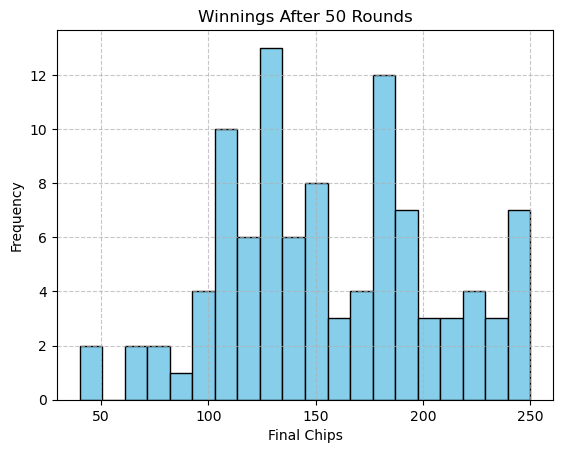

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# Function to simulate 50 rounds of the game
def sim_game(thresh, rounds=50, start=200):
    chips = start  # Start with 200 chips
    for _ in range(rounds):
        count = np.random.randint(-10, 10)  # Simulate card count
        if count < thresh:  # Hit if count < threshold
            outcome = np.random.choice(["win", "lose", "tie"], p=[0.4, 0.5, 0.1])  # Simulate outcome
            chips += 10 if outcome == "win" else -10  # Update chips based on outcome
    return chips  # Return final chip count

# Parameters
thresh = 0  # Threshold for hitting/standing
n_games = 100  # Number of games to simulate
rounds = 50  # Rounds per game

# Simulate 100 games
wins = [sim_game(thresh, rounds) for _ in range(n_games)]

# Calculate statistics
avg = np.mean(wins) / rounds  # Average winnings per round
std = np.std(wins)  # Standard deviation of final chip counts
win_prob = sum(1 for x in wins if x > 200) / n_games  # Probability of net winning
loss_prob = sum(1 for x in wins if x < 200) / n_games  # Probability of net losing

# Print results
print(f"Avg winnings/round: {avg:.2f}")
print(f"Std dev: {std:.2f}")
print(f"Win prob: {win_prob:.2f}")
print(f"Loss prob: {loss_prob:.2f}")

# Plot histogram of final chip counts
plt.hist(wins, bins=20, edgecolor="black", color="skyblue")
plt.title("Winnings After 50 Rounds")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Threshold: -3
Avg winnings/round: 3.33
Std dev: 35.45
Win prob: 0.14
Loss prob: 0.79



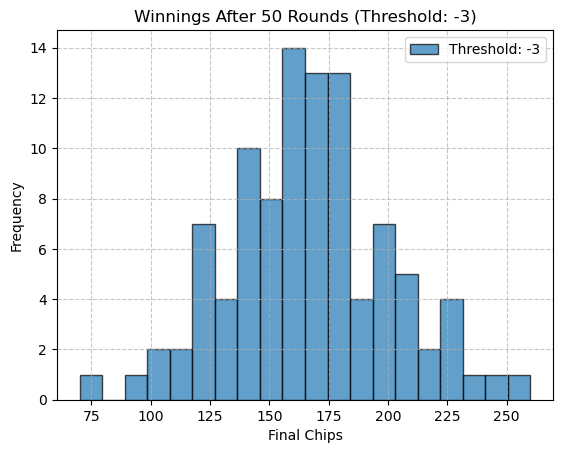

Threshold: -2
Avg winnings/round: 3.29
Std dev: 43.28
Win prob: 0.20
Loss prob: 0.78



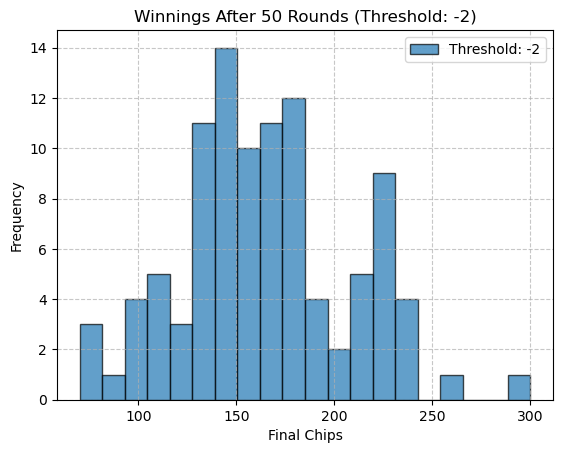

Threshold: -1
Avg winnings/round: 2.98
Std dev: 48.25
Win prob: 0.11
Loss prob: 0.82



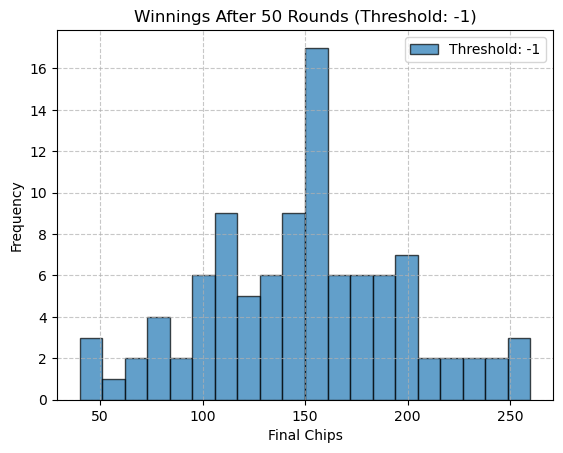

Threshold: 0
Avg winnings/round: 3.13
Std dev: 46.55
Win prob: 0.12
Loss prob: 0.81



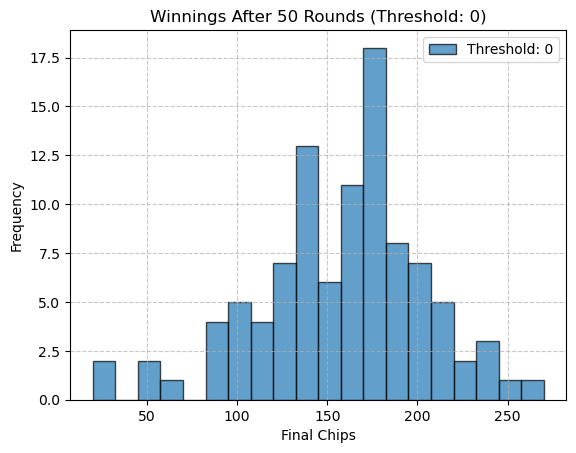

Threshold: 1
Avg winnings/round: 2.80
Std dev: 47.63
Win prob: 0.11
Loss prob: 0.85



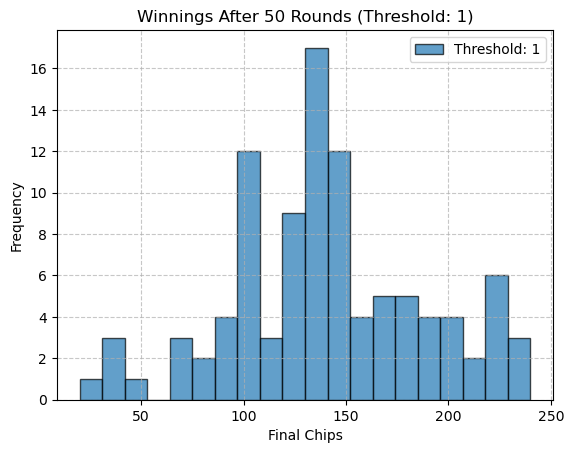

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Function to simulate 50 rounds of the game
def sim_game(thresh, rounds=50, start=200):
    chips = start  # Start with 200 chips
    for _ in range(rounds):
        count = np.random.randint(-10, 10)  # Simulate card count
        if count < thresh:  # Hit if count < threshold
            outcome = np.random.choice(["win", "lose", "tie"], p=[0.4, 0.5, 0.1])  # Simulate outcome
            chips += 10 if outcome == "win" else -10  # Update chips based on outcome
    return chips  # Return final chip count

# Step 9: Test different thresholds
thresholds = [-3, -2, -1, 0, 1]
n_games = 100  # Number of games to simulate
rounds = 50  # Rounds per game

for thresh in thresholds:
    wins = [sim_game(thresh, rounds) for _ in range(n_games)]
    avg = np.mean(wins) / rounds  # Average winnings per round
    std = np.std(wins)  # Standard deviation of final chip counts
    win_prob = sum(1 for x in wins if x > 200) / n_games  # Probability of net winning
    loss_prob = sum(1 for x in wins if x < 200) / n_games  # Probability of net losing

    print(f"Threshold: {thresh}")
    print(f"Avg winnings/round: {avg:.2f}")
    print(f"Std dev: {std:.2f}")
    print(f"Win prob: {win_prob:.2f}")
    print(f"Loss prob: {loss_prob:.2f}")
    print()

    # Plot histogram for this threshold
    plt.hist(wins, bins=20, edgecolor="black", alpha=0.7, label=f"Threshold: {thresh}")
    plt.title(f"Winnings After 50 Rounds (Threshold: {thresh})")
    plt.xlabel("Final Chips")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()  # Display the histogram

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased winnings. 

New Strategy (Threshold: -4)
Avg winnings/round: 3.36
Std dev: 34.79
Win prob: 0.15
Loss prob: 0.77


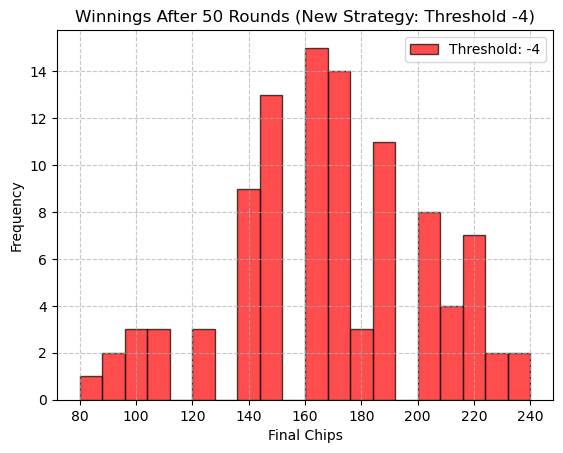

In [99]:
# Step 10: Test a new strategy (e.g., threshold = -4)
new_thresh = -4
wins = [sim_game(new_thresh, rounds) for _ in range(n_games)]
avg = np.mean(wins) / rounds
std = np.std(wins)
win_prob = sum(1 for x in wins if x > 200) / n_games
loss_prob = sum(1 for x in wins if x < 200) / n_games

print(f"New Strategy (Threshold: {new_thresh})")
print(f"Avg winnings/round: {avg:.2f}")
print(f"Std dev: {std:.2f}")
print(f"Win prob: {win_prob:.2f}")
print(f"Loss prob: {loss_prob:.2f}")

# Plot histogram for the new strategy
plt.hist(wins, bins=20, edgecolor="black", color="red", alpha=0.7, label=f"Threshold: {new_thresh}")
plt.title(f"Winnings After 50 Rounds (New Strategy: Threshold {new_thresh})")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.show()